#### Цель eda

Понять структуру и качество исходных данных Titanic, найти связи признаков с `Survived`, сформировать и обосновать гипотезы для feature engineering и baseline модели.

In [1]:
from pathlib import Path
from matplotlib.ticker import PercentFormatter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Загрузка и контракт данных

На этом этапе проверяем размеры train/test, их схему, различия колонок, целевую переменную и технический идентификатор.

In [2]:
# Формируем путь к папке с исходными данными
data_dir = Path('../data/raw')

# Читаем CSV в DataFrame
df_train = pd.read_csv(data_dir/'train.csv')
df_test = pd.read_csv(data_dir/'test.csv')

In [3]:
print(f'train: {df_train.shape[0]} строк, {df_train.shape[1]} стобцов')
print(f'test: {df_test.shape[0]} строк, {df_test.shape[1]} стобцов')

train: 891 строк, 12 стобцов
test: 418 строк, 11 стобцов


In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df_train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

| Признак | Тип | Описание |
|---|---|---|
| `PassengerId` | идентификатор | Уникальный номер пассажира в датасете |
| `Survived` | target | Выжил пассажир или нет: `0` — нет, `1` — да |
| `Pclass` | категориальный | Класс билета: `1`, `2` или `3` |
| `Name` | текстовый | Полное имя пассажира |
| `Sex` | категориальный | Пол пассажира |
| `Age` | числовой | Возраст в годах |
| `SibSp` | числовой | Число братьев, сестёр и супругов на борту |
| `Parch` | числовой | Число родителей и детей на борту |
| `Ticket` | текстовый | Номер билета |
| `Fare` | числовой | Стоимость билета |
| `Cabin` | текстовый | Номер каюты |
| `Embarked` | категориальный | Порт посадки: `C` — Cherbourg, `Q` — Queenstown, `S` — Southampton |

Различия в атрибутах между train и test

In [6]:
print(f'Только в train: {set(df_train.columns) - set(df_test.columns)}')
print(f'Только в test: {set(df_test.columns) - set(df_train.columns)}')

Только в train: {'Survived'}
Только в test: set()


#### 2. Качество данных

На этом этапе проверим дубликаты строк; фактические типы и смысл признаков; допустимые значения категориальных признаков; диапазоны числовых признаков и возможные аномалии; повторяемость `Name`, `Ticket` и `Cabin`; сходство распределений в train и test.

In [7]:
print('Дубликаты в train: ', df_train.duplicated().sum())
print('Дубликаты в test: ', df_test.duplicated().sum())

Дубликаты в train:  0
Дубликаты в test:  0


Дубликат означал бы, что все поля пассажира совпали включая `PassengerId`. Повторяющиеся `Ticket` или `Cabin` не являются дубликатами строк: несколько пассажиров могли ехать по одному билету или находиться в одной каюте.

Типы признаков

Pandas хранит `Pclass`, `SibSp` и `Parch` как числа однако их смысл различается:

- `Pclass` — категориальный порядковый признак;
- `SibSp` и `Parch` — счетчики;
- `Age` и `Fare` — непрерывные числовые признаки;
- `Name`, `Ticket` и `Cabin` — текстовые или смешанные признаки;
- `Sex` и `Embarked` — категориальные признаки.

In [8]:
categorial_columns = ['Survived', 'Pclass', 'Sex', 'Embarked']
for column in categorial_columns:
    values = sorted(df_train[column].dropna().unique())
    print(f'{column}: {values}')

Survived: [np.int64(0), np.int64(1)]
Pclass: [np.int64(1), np.int64(2), np.int64(3)]
Sex: ['female', 'male']
Embarked: ['C', 'Q', 'S']


Диапазоны и возможные аномалии в числовых признаках

In [9]:
numeric_columns = ['Age', 'SibSp', 'Parch', 'Fare']
df_train[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


`Age` заполнен только у 714 из 891 пассажира и 177 значений отсутсвуют. Возраст лежит в диапазоне от 0.42 до 80.00 лет, в данных есть младенцы и старики. Медианный возраст 28 лет.

`SibSp` и `Parch` имеют много нулей: как минимум 75% пассажиров имеют не более одного родственника типа sibling/spouse и не более нуля родственников типа parent/child. Большинство пассажиров путешевствовали бещ таких родственников. Значения 8 и 6 редкие, но сами по себе не выглядят ошибкой.

`Fare` имеет выраженное правостороннее распределение: среднее значение 32.2 заметно выше медианы 14.45, а максимум 512.33 намного выше третьего квартиля. Дорогие билеты следует отдельно посмотреть на графике и в связке с `Pclass`.

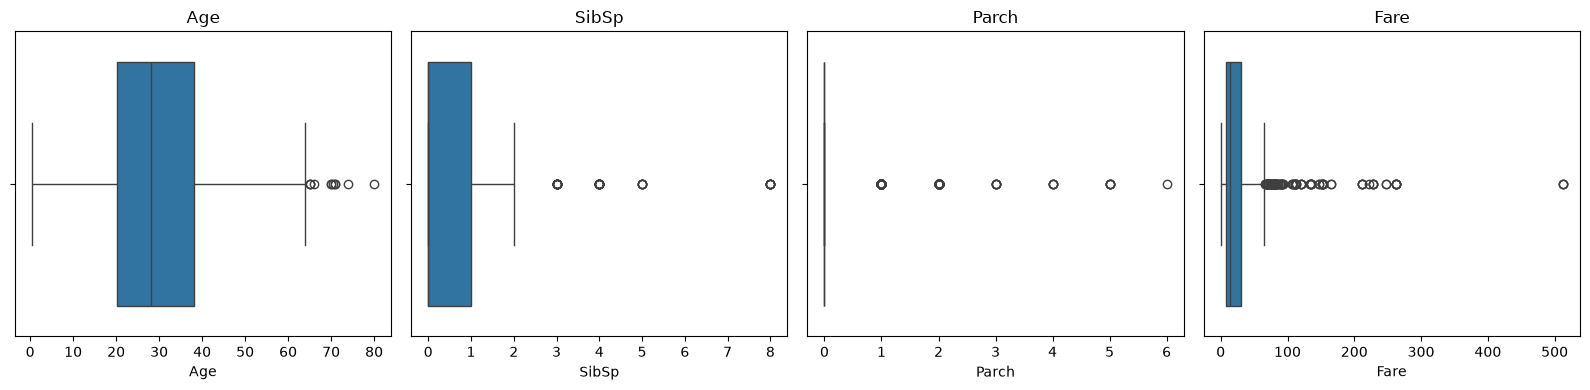

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, column in zip(axes, numeric_columns):
    sns.boxplot(data=df_train, x=column, ax=ax)
    ax.set_title(column)

plt.tight_layout()

Повторяемость `Name`, `Ticket`, `Cabin`

In [11]:
text_columns = ['Name', 'Ticket', 'Cabin']

repeatability = pd.DataFrame(index=text_columns)
repeatability['Заполнено'] = df_train[text_columns].notna().sum()
repeatability['Уникальных значений'] = df_train[text_columns].nunique()
repeatability['Повторяющихся строк'] = repeatability['Заполнено'] - repeatability['Уникальных значений']

repeatability

,Заполнено,Уникальных значений,Повторяющихся строк
Name,891,891,0
Ticket,891,681,210
Cabin,204,147,57


Примеры пассажиров с общими билетами

In [12]:
is_shared = df_train["Ticket"].duplicated(keep=False)
columns = ["Ticket", "Name", "Pclass", "Fare", "Cabin"]

shared_tickets = df_train.loc[is_shared, columns].sort_values("Ticket")
shared_tickets

,Ticket,Name,Pclass,Fare,Cabin
257,110152,"Cherry, Miss. Gladys",1,86.500,B77
759,110152,"Rothes, the Countess. of (Lucy Noel Martha Dye...",1,86.500,B77
504,110152,"Maioni, Miss. Roberta",1,86.500,B79
262,110413,"Taussig, Mr. Emil",1,79.650,E67
558,110413,"Taussig, Mrs. Emil (Tillie Mandelbaum)",1,79.650,E67
...,...,...,...,...,...
736,W./C. 6608,"Ford, Mrs. Edward (Margaret Ann Watson)",3,34.375,NaN
86,W./C. 6608,"Ford, Mr. William Neal",3,34.375,NaN
147,W./C. 6608,"Ford, Miss. Robina Maggie ""Ruby""",3,34.375,NaN
540,WE/P 5735,"Crosby, Miss. Harriet R",1,71.000,B22


Повторяющиеся билеты могут стать основой для будущих признаков, например размера группы пассажирова с одним билетом.

Сравнение распределений train и test

In [13]:
df_comparison = pd.concat(
    [
        df_train.assign(dataset='train'),
        df_test.assign(dataset='test')
    ],
    ignore_index=True
)

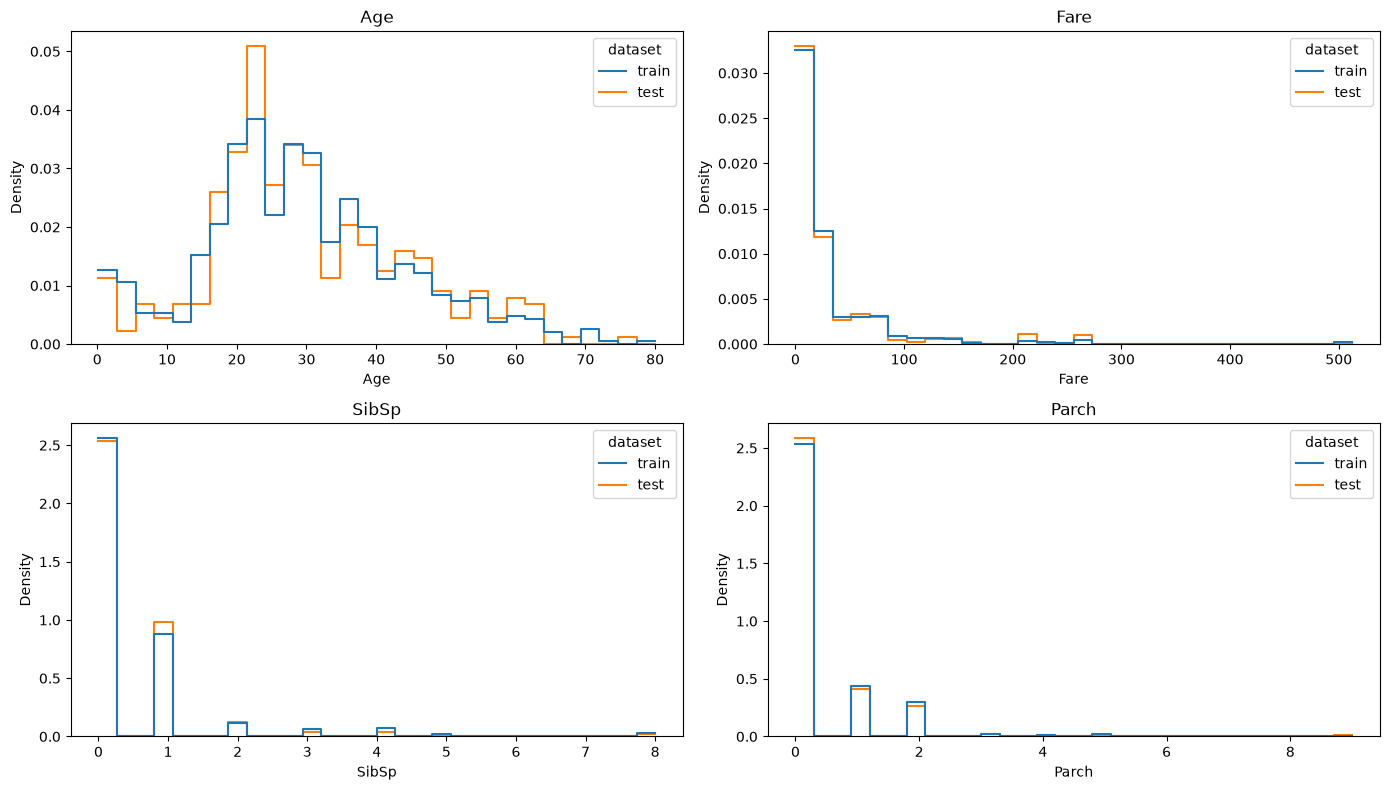

In [14]:
comparison_numeric_columns = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, column in zip(axes, comparison_numeric_columns):
    sns.histplot(
        data=df_comparison,
        x=column,
        hue='dataset',
        bins=30,
        stat='density',
        common_norm=False,
        element='step',
        fill=False,
        ax=ax
    )
    ax.set_title(column)

plt.tight_layout()

Распределение `Age` в train и test в целом похоже: основная часть пассажиров находится в диапазоне 18-40 лет. Небольшие локальные раздичия объяснимы меньшим размером test-выборки.

`Fare` в обеих выборках имеет выраженный правый хвост: большинство билетов дешевые, дорогие встречаются редко. Test выборка весьма репрезентативна и близка к набору на котором мы будем обучаться.

Распределение `SibSp` ии `Parch` практически совпадают: большинство пассажирова путешевствовали без родственников.

Значимых различий между train и test по рассмотренным числовым признакам не обнаружено. Train можно считать достаточно репрезентативным для test./

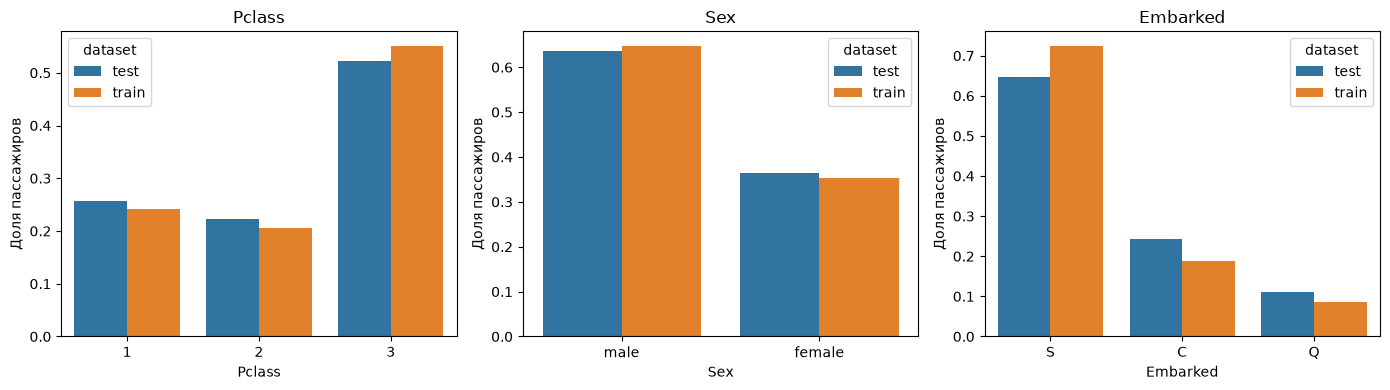

In [15]:
comparison_categorical_columns = ['Pclass', 'Sex', 'Embarked']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, column in zip(axes, comparison_categorical_columns):
    shares = (
        df_comparison
        .groupby('dataset')[column]
        .value_counts(normalize=True)
        .rename('share')
        .reset_index()
    )
    sns.barplot(
        data=shares,
        x=column,
        y='share',
        hue='dataset',
        errorbar=None,
        ax=ax
    )
    ax.set_title(column)
    ax.set_ylabel('Доля пассажиров')

plt.tight_layout()

Вывод по качеству данных

- Полных дубликатов строк в train и test не обнаружено.

- Категориальные признаки содержат ожидаемые значения: `Survived` принимает значения `0` и `1`, `Pclass` — классы от `1` до `3`, `Sex` — `female` и `male`, `Embarked` — `C`, `Q` и `S`.

- Возраст `Age` находится в правдоподобном диапазоне от младенцев до 80 лет, однако часть значений отсутствует. Пропуски будут подробно рассмотрены отдельно.

- `SibSp` и `Parch` имеют много нулевых значений: большая часть пассажиров путешествовала без родственников соответствующего типа. Редкие большие значения не выглядят ошибками, а отражают большие семьи.

- `Fare` имеет выраженный правый хвост: большинство билетов относительно дешёвые, но присутствуют редкие очень дорогие билеты. Статистические выбросы по `Fare` не следует автоматически удалять, поскольку они могут быть реальными тарифами первого класса или групповыми билетами.

- `Name` выглядит почти уникальным для каждого пассажира. Повторяющиеся `Ticket` и заполненные значения `Cabin` могут отражать группы совместно путешествовавших пассажиров и потенциально содержать полезный сигнал для будущих признаков.

- Распределения основных признаков в train и test в целом похожи. Значимого сдвига между выборками не видно, поэтому train можно считать репрезентативной выборкой для построения модели для test.

#### 3. Целевая переменная

Целевая переменная — `Survived`. Где 0 — пассажир не выжил, 1 — пассажир выжил. На этом этапе посмотрим, сколько объектов каждого класса есть в обучающей выборке, насколько сбалансированны и какой результат даст простейшее предсказание без признаков.

Распределение `Survived`

In [16]:
target_summary = df_train['Survived'].value_counts().sort_index().to_frame('Количество')
target_summary['Доля'] = target_summary['Количество'] / len(df_train)
target_summary

,Количество,Доля
Survived,,
0,549,0.616162
1,342,0.383838


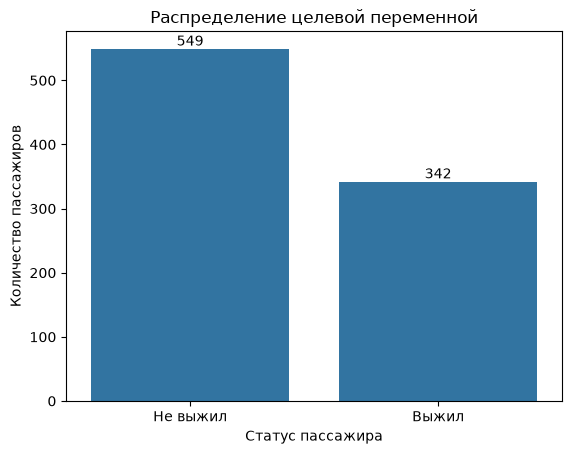

In [17]:
ax = sns.countplot(data=df_train, x='Survived', order=[0, 1])

ax.set(
    title='Распределение целевой переменной',
    xlabel='Статус пассажира',
    ylabel='Количество пассажиров'
)

ax.set_xticks([0, 1], ['Не выжил', 'Выжил'])
ax.bar_label(ax.containers[0])

plt.show()

В train не выжили 549 пассажиров (около 61.6%), выжили 342 пассажира (около 38.4%). Классы несбалансированы, но дисбаланс умеренный: выживших достаточно много, поэтому на текущем этапе не нужны специальные методы балансировки классов.

In [18]:
print(f'Naive baseline accuracy: {(df_train['Survived'] == 0).mean():.2%}')

Naive baseline accuracy: 61.62%


Вывод по целевой переменной

- `Survived` бинарная целевая переменная.

- В датасете больше невыживших пассажиров чем выживших.

- Дисбаланс классов умеренный: он влияет на интерпретацию accuracy, но пока не требует специальных техник.

- Простое предсказание "никто не выжил" дает accuracy около 61.6%.

#### 4. Анализ отдельных признаков

В этом разделе признаки изучаются отдельно от `Survived`. Цель — понять распределение и внутреннюю структуру признаков, а также найти идеи для будущего feature engineering.

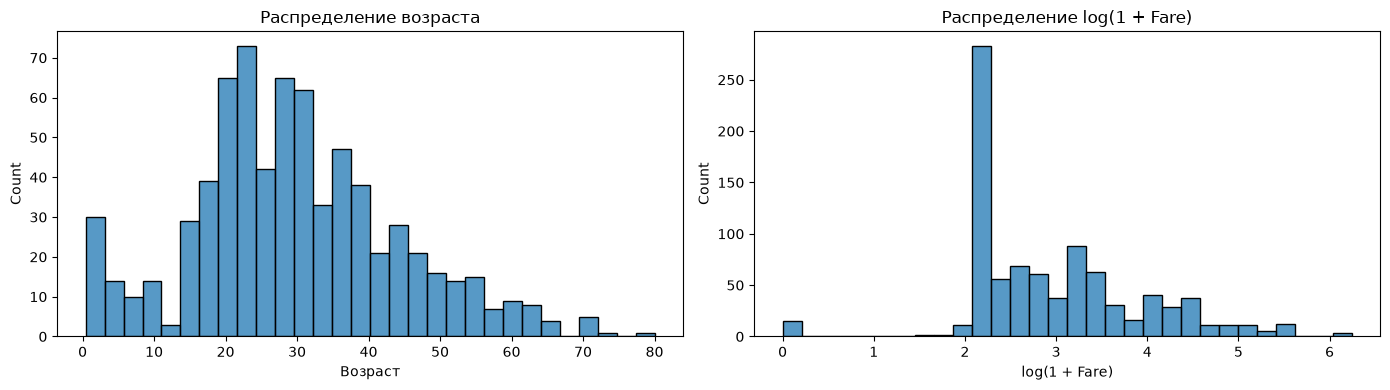

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df_train, x='Age', bins=30, ax=axes[0])
axes[0].set_title('Распределение возраста')
axes[0].set_xlabel('Возраст')

sns.histplot(np.log1p(df_train['Fare']), bins=30, ax=axes[1])
axes[1].set_title('Распределение log(1 + Fare)')
axes[1].set_xlabel('log(1 + Fare)')

plt.tight_layout()

`Fare` имеет длинный правый хвост, поэтому он плохо читаетс в исходном масштабе. `log(1 + Fare)` сжимает большие значения и делает форму распределения более наглядной.

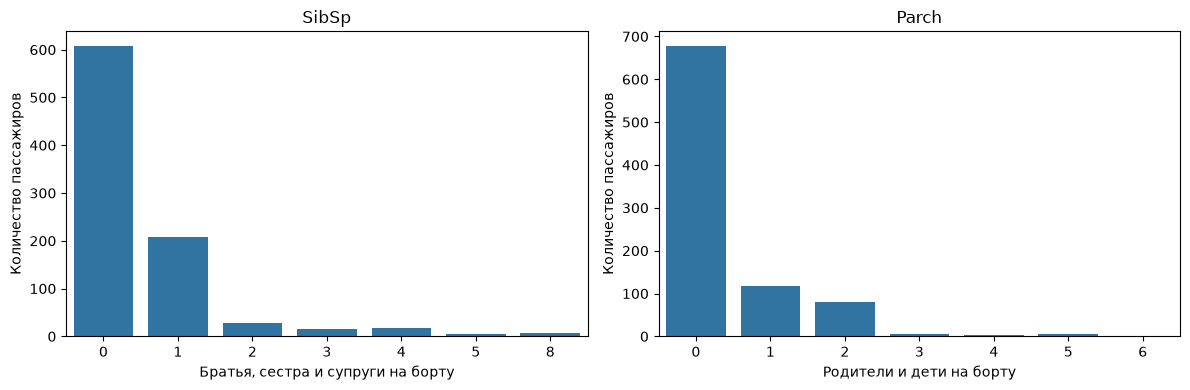

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_train, x='SibSp', ax=axes[0])
axes[0].set_title('SibSp')
axes[0].set_xlabel('Братья, сестра и супруги на борту')
axes[0].set_ylabel('Количество пассажиров')

sns.countplot(data=df_train, x='Parch', ax=axes[1])
axes[1].set_title('Parch')
axes[1].set_xlabel('Родители и дети на борту')
axes[1].set_ylabel('Количество пассажиров')

plt.tight_layout()

В обоих признаках доминирует ноль: многие пассажиры путешевствовали без родственников соответсвующего типа. Позже имеет смысл проверить общий размер семьи: `FamilySize = SibSp + Parch + 1`. Плюс 1 потому что добавляем самого пассажира.

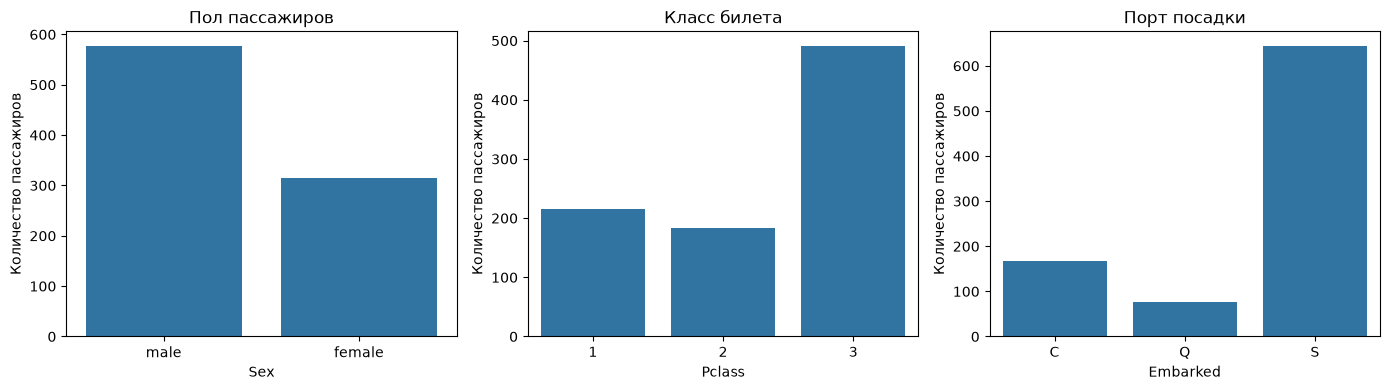

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=df_train, x='Sex', order=['male', 'female'], ax=axes[0])
axes[0].set_title('Пол пассажиров')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Количество пассажиров')

sns.countplot(data=df_train, x='Pclass', order=[1, 2, 3], ax=axes[1])
axes[1].set_title('Класс билета')
axes[1].set_xlabel('Pclass')
axes[1].set_ylabel('Количество пассажиров')

sns.countplot(data=df_train, x='Embarked', order=['C', 'Q', 'S'], ax=axes[2])
axes[2].set_title('Порт посадки')
axes[2].set_xlabel('Embarked')
axes[2].set_ylabel('Количество пассажиров')

plt.tight_layout()

Мужчин в обучающей выборка больше, чем женщин. Пассажиров третьего класс больше всего. Большинство пассажиров сели в Southampton.

In [22]:
title = (
    df_train['Name']
    .str.extract(r',\s*([^.]*)\.')[0]
    .str.strip()
)

title.value_counts()

0
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Из `Name` можно извлечь образение пассажира: `Mr`, `Mrs`, `Miss`, `Master` и более редкие варианты. Обращение потенциально содержит информацию о поле, возрасте, семейном или социальном статусе. Позже можно создать признак `Title` и объединить редкие обращения в общую категорию.

In [23]:
ticket_group_sizes = df_train.groupby("Ticket").size()

ticket_group_distribution = (
    ticket_group_sizes
    .value_counts()
    .sort_index()
    .rename_axis("Размер группы, пассажиров")
    .reset_index(name="Количество групп")
)

display(ticket_group_distribution.style.hide(axis="index"))

"Размер группы, пассажиров",Количество групп
1,547
2,94
3,21
4,11
5,2
6,3
7,3


Групой считаются пассажиры из train с одинаковым значением `Ticket`. Строка с индексом `1` показывает число билетов, принадлежащих одному пассажиру; строка с индексом `2` — число билетов, которыми пользовались два пассажира.

Общий билет может означать, что пассажиры путешествовали группой. Позднее можно проверить признак `TicketGroupSize`.

In [24]:
deck = df_train['Cabin'].str[0].fillna('Unkown')
deck.value_counts()

Cabin
Unkown    687
C          59
B          47
D          33
E          32
A          15
F          13
G           4
T           1
Name: count, dtype: int64

В `Cabin` видна структура "буквенный префикс + номер", буквенный префикс соответствует палубе (потому что мы знаем, что это так). Извлечем его позже как кандидат на признак `Deck` (первая буква `Cabin`) и `CabinMissing` (был ли номер каюты указан).

Вывод по отдельным признакам

- `Age` требует отдельной обработки пропусков; полезно также проверить возрастные группы.

- Распределение `Fare` сильно скошено вправо, поэтому стоит рассмотреть `log1p(Fare)` для моделей, чувствительных к масштабу признаков.

- `SibSp` и `Parch` можно объединить в признак размера семьи.

- `Sex`, `Pclass` и `Embarked` — компактные категориальные признаки, готовые к дальнейшему анализу.

- `Name` содержит полезную структуру в виде обращения пассажира.

- Повторяющиеся `Ticket` могут отражать размер группы путешественников.

- `Cabin` содержит информацию о палубе, но имеет много пропусков.

#### 5. Пропуски

In [25]:
feature_columns = df_test.columns

missing_summary = pd.DataFrame(
    {
        'Пропусков в train': df_train[feature_columns].isna().sum(),
        'Доля в train': df_train[feature_columns].isna().mean(),
        'Пропусков в test': df_test[feature_columns].isna().sum(),
        'Доля в test': df_test[feature_columns].isna().mean()
    }
)

predicate = (missing_summary['Пропусков в train'] > 0) | (missing_summary['Пропусков в test'] > 0)
missing_summary = missing_summary[predicate].sort_values('Доля в train', ascending=False)

display(
    missing_summary.style.format(
        {
            'Доля в train': '{:.1%}',
            'Доля в test': '{:.1%}'
        }
    )
)

,Пропусков в train,Доля в train,Пропусков в test,Доля в test
Cabin,687,77.1%,327,78.2%
Age,177,19.9%,86,20.6%
Embarked,2,0.2%,0,0.0%
Fare,0,0.0%,1,0.2%


Сравним доли пропусков

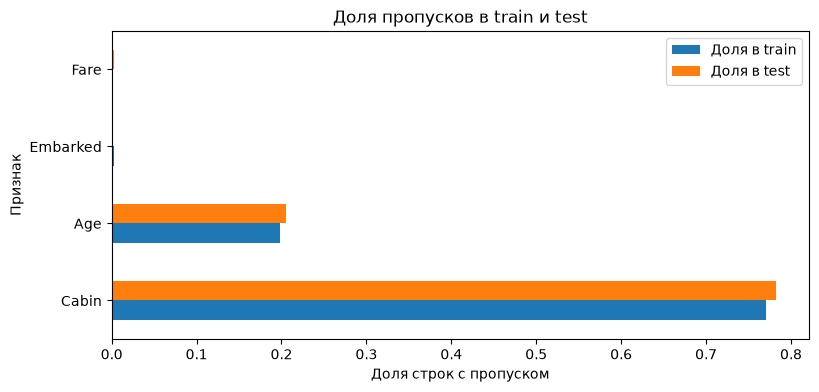

In [26]:
ax = missing_summary[['Доля в train', 'Доля в test']].plot(
    kind='barh',
    figsize=(9, 4)
)

ax.set(
    title='Доля пропусков в train и test',
    xlabel='Доля строк с пропуском',
    ylabel='Признак'
)

plt.show()

Похожие доли пропусков в train и test означают, что проблема с пропусками устроена примерно одинаково в обеих выборках. Для соревнования наблюдаем: `Cabin` отсутсвует примерно у 77-78% пассажиров; `Age` отсутсвует примерно у 20% пассажиров; `Embarked` пропущен только у двух пассажиров в train; `Fare` заполнен в train, но имеет один прпоуск в test.

Проверим, отличается ли доля выживших среди пассажиров с заполненным и пропущенным значением. Для `Fare` такой проверки не делаем потому что в train нет пропуском.

In [27]:
columns_with_missing = ["Age", "Cabin", "Embarked"]
rows = []

for column in columns_with_missing:
    is_missing = df_train[column].isna()
    rows.append(
        {
            "Признак": column,
            "Выживаемость: значение указано": df_train.loc[
                ~is_missing, "Survived"
            ].mean(),
            "Выживаемость: значение пропущено": df_train.loc[
                is_missing, "Survived"
            ].mean(),
            "Число пропусков": is_missing.sum(),
        }
    )

missingness_signal = pd.DataFrame(rows)

display(
    missingness_signal.style
    .hide(axis='index')
    .format(
        {
            "Выживаемость: значение указано": "{:.1%}",
            "Выживаемость: значение пропущено": "{:.1%}",
        }
    )
)

Признак,Выживаемость: значение указано,Выживаемость: значение пропущено,Число пропусков
Age,40.6%,29.4%,177
Cabin,66.7%,30.0%,687
Embarked,38.2%,100.0%,2


У пассажиров с пропущенным `Age` доля выживших ниже, чем у пассажиров с известным возрастом 29.4% против 40.6%. Отсутствие возраста не выглядит полностью случайным и может быть кандидатом на бинарный признак `AgeMissing`.

Разница для `Cabin` ещё заметнее — среди пассажиров с указанной каютой выжили 66.7%, а среди пассажиров без каюты 30.0%. Следовательно, сам факт наличия или отсутствия номера каюты содержит информацию, связанную с `Survived`. Кандидат на признак — `CabinMissing`.

Причину связи `CabinMissing` с выживаемостью пока не утверждаем. Она может быть связана с классом билета, стоимостью билета, местом размещения на корабле или особенностями заполнения исторических данных.

Для `Embarked` выводы делать нельзя — пропусков только два, поэтому значение 100% выживаемости не является надёжным наблюдением.

Вывод по пропускам

- `Cabin` имеет очень высокую долю пропусков. Удалять столбец сразу не стоит: полезными могут быть и `Deck`, и `CabinMissing`.

- `Age` имеет заметную долю пропусков и потребует отдельной стратегии заполнения. Возможные кандидаты для восстановления возраста — `Title`, `Sex` и `Pclass`.

- `Embarked` имеет только два пропуска в train. Позже их можно заполнить наиболее вероятным портом, но это решение должно быть частью pipeline, а не ручной правкой исходного CSV.

- `Fare` имеет один пропуск только в test. Его также нужно будет заполнить внутри pipeline.

#### 6. Связь признаков с Survied

Для каждой группы будем считать survial rate — среднее значение `Survived`. Так как `Survived` содержит только `0` и `1`, его среднее равно доле выживших.

**Survival rate для категориальных признаков**

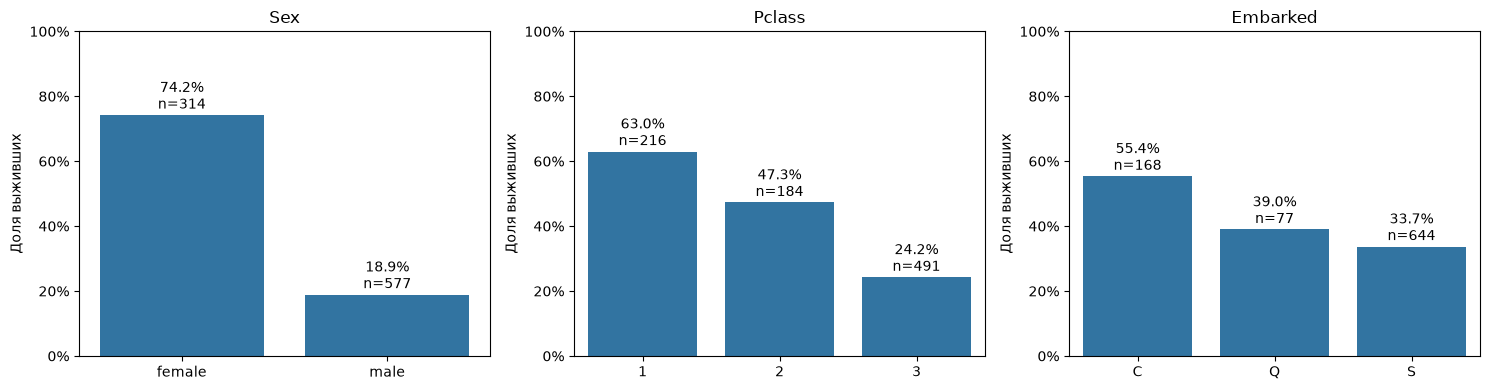

In [28]:
category_orders = {
    'Sex': ['female', 'male'],
    'Pclass': [1, 2, 3],
    'Embarked': ['C', 'Q', 'S']
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column in zip(axes, category_orders):
    summary = (
        df_train
        .groupby(column, observed=True)['Survived']
        .agg(Выживаемость='mean', Пассажиров='size')
        .reindex(category_orders[column])
        .reset_index()
    )
    sns.barplot(
        data=summary,
        x=column,
        y='Выживаемость',
        errorbar=None,
        ax=ax
    )
    ax.set_title(column)
    ax.set_xlabel('')
    ax.set_ylabel('Доля выживших')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1))

    for bar, rate, count in zip(ax.patches, summary['Выживаемость'], summary['Пассажиров']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{rate:.1%}\nn={count}",
            ha="center",
        )

plt.tight_layout()

У женщин survival rate значительно выше, чем у мужчин; с понижением класса билета survival rate уменьшается; survival rate различается и по `Embarked`, но этот признак может быть связан с составом пассажиров в каждом порту, например с классом билета. Отдельно считать это причинной связью нельзя.

**Возрастные интервалы**

In [29]:
age_band = pd.cut(
    df_train['Age'],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=['0-12', '13-18', '19-35', '36-60', '61+']
)

age_summary = (
    df_train
    .groupby(age_band, observed=True)['Survived']
    .agg(Выживаемость='mean', Пассажиров='size')
    .reset_index()
)

age_summary

,Age,Выживаемость,Пассажиров
0,0-12,0.579710,69
1,13-18,0.428571,70
2,19-35,0.382682,358
3,36-60,0.400000,195
4,61+,0.227273,22


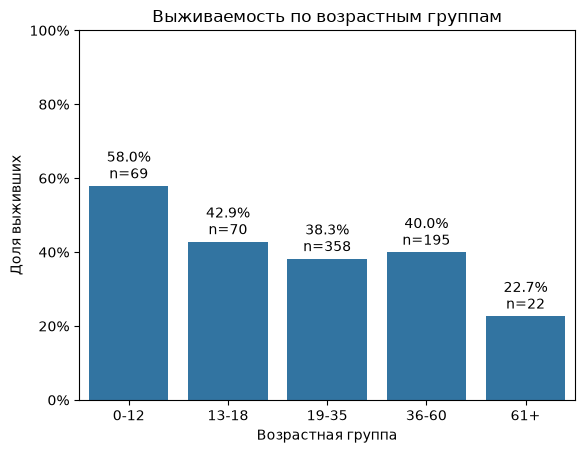

In [30]:
ax = sns.barplot(
    data=age_summary,
    x='Age',
    y='Выживаемость',
    errorbar=None
)

ax.set(
    title='Выживаемость по возрастным группам',
    xlabel='Возрастная группа',
    ylabel='Доля выживших',
    ylim=(0, 1)
)

ax.yaxis.set_major_formatter(PercentFormatter(1))

for bar, rate, count in zip(ax.patches, age_summary['Выживаемость'], age_summary['Пассажиров']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{rate:.1%}\nn={count}',
        ha='center'
    )

plt.show()

Позже стоит проверить, улучшает ли модель возраст как непрерывное значение, возрастные интервалы или комбинация возраста с полом и классом билета.

**Тарифные интервалы**

In [31]:
fare_band = pd.qcut(
    df_train["Fare"],
    q=4,
    precision=2,
).rename('Тарифный интервал')

fare_summary = (
    df_train
    .groupby(fare_band, observed=True)["Survived"]
    .agg(Выживаемость="mean", Пассажиров="size")
    .reset_index()
)

display(
    fare_summary.style
    .hide(axis="index")
    .format({"Выживаемость": "{:.1%}"})
)

Тарифный интервал,Выживаемость,Пассажиров
"(-0.01, 7.91]",19.7%,223
"(7.91, 14.45]",30.4%,224
"(14.45, 31.0]",45.5%,222
"(31.0, 512.33]",58.1%,222


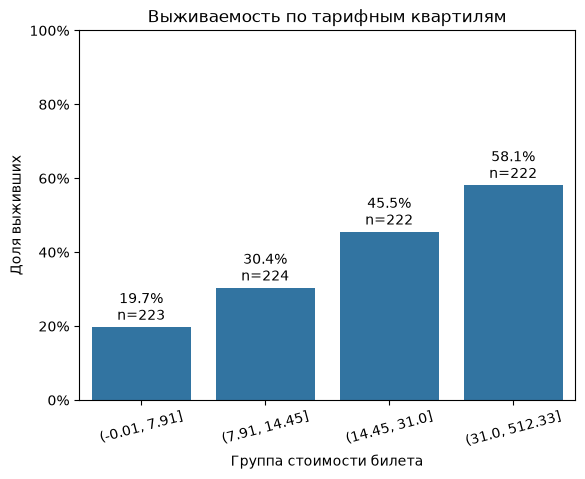

In [32]:
ax = sns.barplot(
    data=fare_summary,
    x='Тарифный интервал',
    y='Выживаемость',
    errorbar=None
)

ax.set(
    title='Выживаемость по тарифным квартилям',
    xlabel='Группа стоимости билета',
    ylabel='Доля выживших',
    ylim=(0, 1)
)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis='x', rotation=15)

for bar, rate, count in zip(ax.patches, fare_summary['Выживаемость'], fare_summary['Пассажиров']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{rate:.1%}\nn={count}",
        ha="center",
    )

plt.show()

`pd.qcut(..., q=4)` делит пассажиров на четыре группы с примерно одинаковым числом наблюдений (в последней группе есть выброс, но он маленький и не искажает статистику). Так удобнее сравнивать survial rate: в каждом тарифном интервале достаточно пассажиров. 

Выживаемость растет вместе с тарифом, но это еще не значит, что цена билета является причиной — `Fare` тесно связан с классом билета и социальным положением пассажира.

**SibSp и Parch**

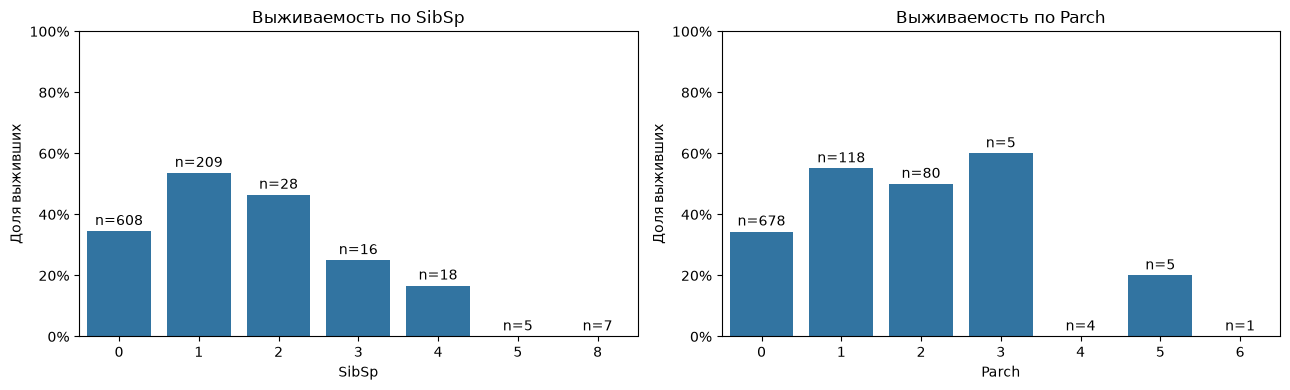

In [33]:
family_columns = ['SibSp', 'Parch']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, column in zip(axes, family_columns):
    summary = (
        df_train
        .groupby(column)['Survived']
        .agg(Выживаемость='mean', Пассажиров='size')
        .reset_index()
    )
    sns.barplot(
        data=summary,
        x=column,
        y='Выживаемость',
        errorbar=None,
        ax=ax
    )
    ax.set(
        title=f'Выживаемость по {column}',
        xlabel=column,
        ylabel='Доля выживших',
        ylim=(0, 1)
    )
    ax.yaxis.set_major_formatter(PercentFormatter(1))

    for bar, rate, count in zip(ax.patches, summary['Выживаемость'], summary['Пассажиров']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'n={count}',
            ha='center'
        )

plt.tight_layout()

Для больших значений `SibSp` и `Parch` пассажиров очень мало. Поэтому резкие изменения survival rate в таких группах нельзя интерпретировать уверенно.

Полезнее смотреть общую гипотезу: одиночные пассажиры, пассажиры с небольшой семьёй и пассажиры с большой семьёй могут иметь разные шансы на выживание. Это аргумент в пользу будущего признака `FamilySize`.

**Корреляции числовых признаков**

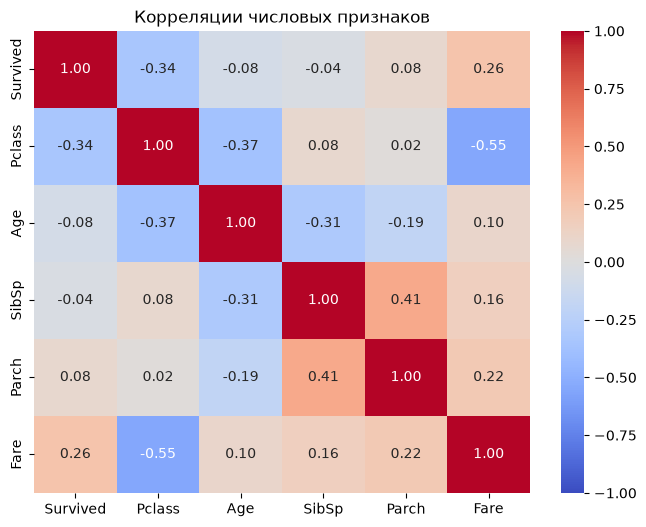

In [34]:
correlation_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
]

correlation_matrix = df_train[correlation_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)

plt.title("Корреляции числовых признаков")
plt.show()

Ограничения heatmap: `Sex`, `Embarked`, `Name`, `Ticket` и `Cabin` не попали в матрицу, хотя могут быть очень полезными; `Pclass` хранится числом, но по смыслу это порядковая категория; корреляция не равна причинности; нелинейные зависимости, например эффект пола или возраста, могут быть сильными при маленькой линейной корреляции.

#### Вывод по связи признаков с Survived

- `Sex` и `Pclass` выглядят наиболее сильными исходными признаками.
- `Fare` связан с выживаемостью, но его эффект необходимо рассматривать вместе с `Pclass`.
- Возраст имеет неоднородную связь с выживаемостью; особенно интересно проверить сочетание возраста и пола.
- `SibSp` и `Parch` по отдельности дают сложную, не обязательно линейную картину. Размер семьи может оказаться информативнее отдельных счётчиков.
- `Embarked` требует осторожной интерпретации: его связь с выживаемостью может объясняться другими признаками.
- Далее нужно проверить взаимодействия признаков: например, `Sex × Pclass`, `Sex × AgeBand` и `Pclass × Fare`.

#### 7. Взаимодействия признаков

Взаимодействие означает, что связь одного признака с `Survived` меняется в зависимости от другого. Например, если survival rate мужчин и женщин различается по-разному в первом, втором и третьем классе, то `Sex` и `Pclass` взаимодействуют. Во всех таблицах и графиках учитываем размер группы: экстремальная survival rate при `n = 3` не является надёжным выводом.

**Sex * Pclass**

In [35]:
sex_pclass_summary = (
    df_train
    .groupby(['Pclass', 'Sex'], observed=True)['Survived']
    .agg(Выживаемость='mean', Пассажиров='size')
    .reset_index()
)

display(
    sex_pclass_summary.style
    .hide(axis='index')
    .format({'Выживаемость': '{:.1%}'})
)

Pclass,Sex,Выживаемость,Пассажиров
1,female,96.8%,94
1,male,36.9%,122
2,female,92.1%,76
2,male,15.7%,108
3,female,50.0%,144
3,male,13.5%,347


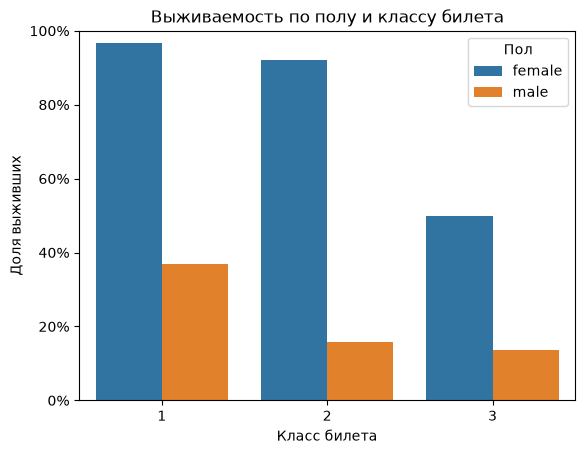

In [36]:
ax = sns.barplot(
    data=sex_pclass_summary,
    x='Pclass',
    y='Выживаемость',
    hue='Sex',
    errorbar=None
)

ax.set(
    title='Выживаемость по полу и классу билета',
    xlabel='Класс билета',
    ylabel='Доля выживших',
    ylim=(0, 1)
)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(title='Пол')

plt.show()

Женщины выживали чаще мужчин во всех классах. У женщин survival rate заметно снижается в третьем классе. У мужчин первый класс заметно отличается от второго и третьего. `Sex` и `Pclass` — ключевые исходные признаки.

**Sex * Возрастная группа**

In [37]:
age_band = pd.cut(
    df_train['Age'],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=['0-12', '13-18', '19-35', '36-60', '61+']
).rename('Возрастная группа')

sex_age_summary = (
    df_train
    .groupby([age_band, 'Sex'], observed=True)['Survived']
    .agg(Выживаемость='mean', Пассажиров='size')
    .reset_index()
)

display(
    sex_age_summary.style
    .hide(axis="index")
    .format({"Выживаемость": '{:.1%}'})
)

Возрастная группа,Sex,Выживаемость,Пассажиров
0-12,female,59.4%,32
0-12,male,56.8%,37
13-18,female,75.0%,36
13-18,male,8.8%,34
19-35,female,78.3%,120
19-35,male,18.1%,238
36-60,female,77.1%,70
36-60,male,19.2%,125
61+,female,100.0%,3
61+,male,10.5%,19


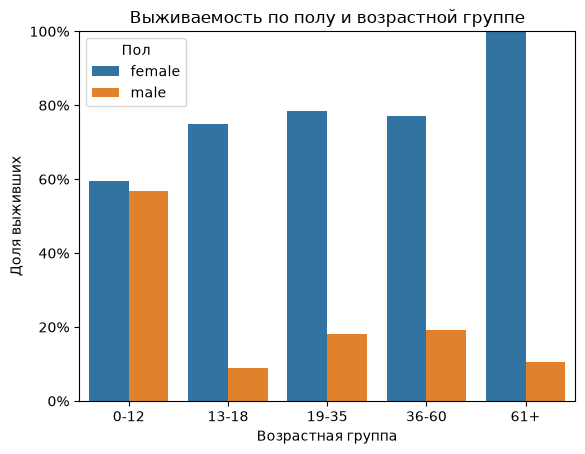

In [38]:
ax = sns.barplot(
    data=sex_age_summary,
    x='Возрастная группа',
    y='Выживаемость',
    hue='Sex',
    errorbar=None,
)

ax.set(
    title='Выживаемость по полу и возрастной группе',
    xlabel='Возрастная группа',
    ylabel='Доля выживших',
    ylim=(0, 1)
)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(title='Пол')

plt.show()

В группе `0–12` выживаемость мальчиков и девочек почти одинакова: около 57–59%. Начиная с `13–18` лет женщины выживали значительно чаще мужчин: примерно 75–78% против 9–19%. Возраст нужно рассматривать вместе с полом: отдельно `Age` скрывает важную разницу между детьми, взрослыми мужчинами и женщинами. Группу `61+` не интерпретируем из-за малого числа пассажиров.

Кандидаты на дальнейшую проверку: признак `IsChild` и взаимодействие `Sex × AgeBand`. Однако оставлять их в модели будем только при улучшении кросс валидации.

**Sex * Размер семьи**

In [39]:
family_size = df_train['SibSp'] + df_train['Parch'] + 1

family_group = pd.cut(
    family_size,
    bins=[0, 1, 4, np.inf],
    labels=['Один', 'Малая семья: 2-4', 'Большая семья: 5+']
).rename('Размер семьи')

family_sex_summary = (
    df_train
    .groupby([family_group, 'Sex'], observed=True)['Survived']
    .agg(Выживаемость='mean', Пассажиров='size')
    .reset_index()
)

display(
    family_sex_summary.style
    .hide(axis='index')
    .format({'Выживаемость': '{:.1%}'})
)

Размер семьи,Sex,Выживаемость,Пассажиров
Один,female,78.6%,126
Один,male,15.6%,411
Малая семья: 2-4,female,80.6%,155
Малая семья: 2-4,male,32.1%,137
Большая семья: 5+,female,27.3%,33
Большая семья: 5+,male,3.4%,29


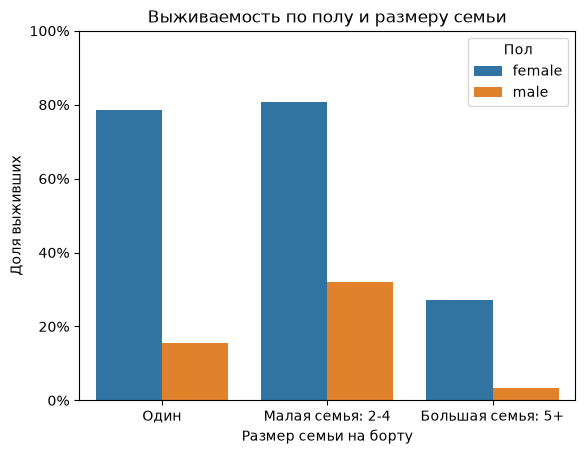

In [40]:
ax = sns.barplot(
    data=family_sex_summary,
    x='Размер семьи',
    y='Выживаемость',
    hue='Sex',
    errorbar=None,
)

ax.set(
    title='Выживаемость по полу и размеру семьи',
    xlabel='Размер семьи на борту',
    ylabel='Доля выживших',
    ylim=(0, 1),
)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(title='Пол')

plt.show()

`FamilySize` — осмысленный кандидат на признак, потому что он объединяет `SibSp` и `Parch` в более интерпретируемую характеристику. Но при этом теряет детали где семья из супруга и семья из ребенка имеют одинаковый `FamilySize = 2` поэтому нужна кросс валидация.

**Embarked * Pclass**

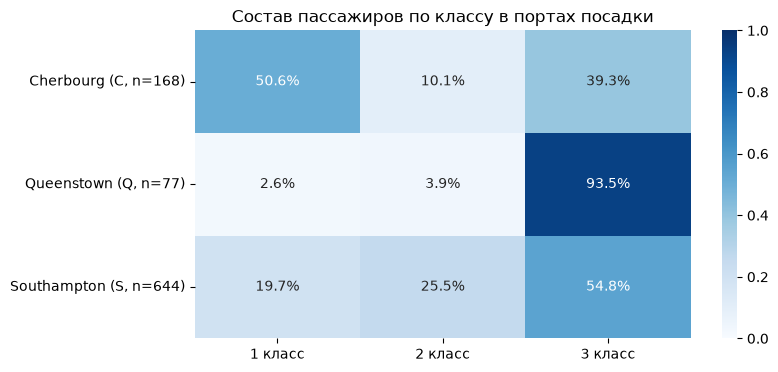

In [41]:
port_order = ['C', 'Q', 'S']

port_names = {
    'C': 'Cherbourg',
    'Q': 'Queenstown',
    'S': 'Southampton'
}

class_mix = (
    pd.crosstab(
        df_train['Embarked'],
        df_train['Pclass'],
        normalize='index'
    )
    .reindex(index=port_order, columns=[1, 2, 3])
)

port_sizes = df_train['Embarked'].value_counts().reindex(port_order)

class_mix.index = [
    f'{port_names[port]} ({port}, n={port_sizes[port]})'
    for port in port_order
]

class_mix.columns = ['1 класс', '2 класс', '3 класс']

plt.figure(figsize=(8, 4))

sns.heatmap(
    class_mix,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    vmin=0,
    vmax=1
)

plt.title('Состав пассажиров по классу в портах посадки')

plt.show()

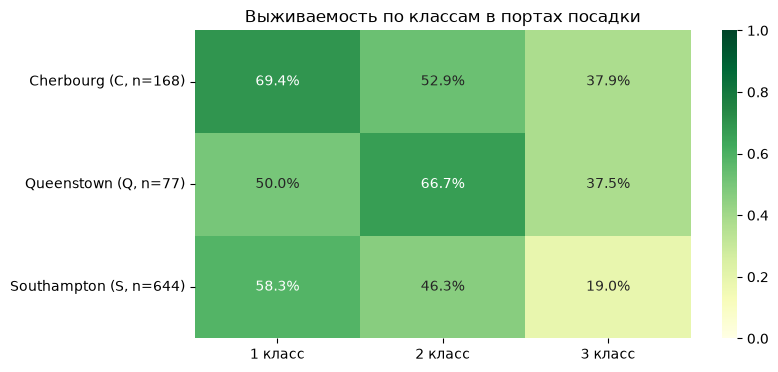

In [42]:
survival_by_port_class = (
    df_train
    .groupby(['Embarked', 'Pclass'], observed=True)['Survived']
    .mean()
    .unstack()
    .reindex(index=port_order, columns=[1, 2, 3])
)

survival_by_port_class.index = [
    f'{port_names[port]} ({port}, n={port_sizes[port]})'
    for port in port_order
]

survival_by_port_class.columns = ['1 класс', '2 класс', '3 класс']

plt.figure(figsize=(8, 4))

sns.heatmap(
    survival_by_port_class,
    annot=True,
    fmt='.1%',
    cmap='YlGn',
    vmin=0,
    vmax=1
)

plt.title('Выживаемость по классам в портах посадки')

plt.show()

Состав пассажиров в портах разный: в `C` больше первого класса, в `Q` почти весь третий класс, в `S` преобладает третий класс. Во всех портах первый класс выживал чаще третьего. Поэтому связь `Embarked` с выживаемостью частично объясняется `Pclass`.

Итог раздела

- `Sex` и `Pclass` — самые сильные исходные признаки;
- Для детей `0–12` различие между полами почти исчезает; после 12 лет выживаемость женщин значительно выше. Кандидат `IsChild`.
- Небольшая семья связана с более высокой выживаемостью, а большая — с низкой. Кандидаты `FamilySize`.
- Различия по `Embarked` частично объясняются разным соотношением классов пассажиров в портах.

#### 8. Итоги EDA и кандидаты на признаки

**Итоги EDA**

- Train и test похожи по основным распределениям; полных дубликатов нет.
- `Age` содержит около 20% пропусков, `Cabin` — около 77%; пропуски сами могут содержать полезный сигнал.
- `Fare` имеет длинный правый хвост.
- Наиболее сильные исходные признаки — `Sex` и `Pclass`.
- Возраст нужно рассматривать вместе с полом: дети отличаются от взрослых мужчин.
- Размер семьи связан с выживаемостью нелинейно: большие семьи выживали хуже.
- Связь `Embarked` с выживаемостью частично объясняется разным составом классов в портах посадки.
- `Fare` связан с `Pclass`, поэтому их эффекты нельзя интерпретировать полностью независимо.

**Кандидаты на новые признаки**

| Признак | Построение | Основание |
|---|---|---|
| `Title` | обращение из `Name` | содержит информацию о поле, возрасте и социальном статусе |
| `FamilyGroup` | `SibSp + Parch + 1`: `Один`, `2–4`, `5+` | размер семьи имеет нелинейную связь с выживанием |
| `AgeMissing` | `Age.isna()` | пропуск возраста связан с другой survival rate |
| `CabinKnown` | `Cabin.notna()` | наличие каюты связано с выживаемостью |
| `Deck` | первая буква `Cabin` | соответствует палубе и может отражать размещение пассажира |
| `IsChild` | `Age <= 12` | дети отличаются от взрослых мужчин по выживаемости |
| `FareLog` | `log1p(Fare)` | уменьшает влияние длинного правого хвоста |
| `SexPclass` | взаимодействие `Sex × Pclass` | эффект пола различается между классами |

`Name`, `Ticket`, `Cabin` и `PassengerId` не используются в исходном виде. Полезность каждого кандидата нужно подтвердить на cross-validation.